### 7. High-gap influence analysis

## Input
- `data/processed/6_lexicon_affect.csv` 

Main questions:
1. Do posts with a higher count/proportion of high-gap words show larger expected_gap_mag?
2. Does high-gap word usage predict expected_gap_mag after controlling for post length, coverage, user and mh_flag?
3. Do high-gap words matter more than a matched set of non-high-gap affective words?
4. In an ablation test, does removing high-gap words reduce the L1-L2 gap at a post level, more than removing matched control words?

In [8]:
import ast
import json
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, mannwhitneyu, wilcoxon
import statsmodels.formula.api as smf
from tqdm.auto import tqdm

tqdm.pandas()

In [9]:
REPO_ROOT = Path.cwd()

# Try to use config if available; otherwise fall back to default folders.
processed_dir = REPO_ROOT / ".." / "data" / "processed"
tables_dir = REPO_ROOT / ".." / "reports" / "tables"
figures_dir = REPO_ROOT / ".." / "reports" / "figures"

try:
    import sys
    sys.path.insert(0, str(REPO_ROOT / ".." / "src"))
    from l2affect.utils.config import load_config, resolve  # type: ignore

    cfg = load_config(REPO_ROOT / ".." / "configs" / "config.yaml")
    processed_dir = resolve(cfg["paths"]["processed_dir"])
    tables_dir = resolve(cfg["paths"]["reports_tables_dir"])
    figures_dir = resolve(cfg["paths"]["reports_figures_dir"])
except Exception as e:
    print("Config not loaded (ok). Using default folders.")
    print("Reason:", e)

processed_dir.mkdir(parents=True, exist_ok=True)
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

processed_dir, tables_dir, figures_dir

(WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/data/processed'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/tables'),
 WindowsPath('C:/Users/hus44/Code/Directed-Reading-Project/reports/figures'))

In [10]:
vad_path = processed_dir / "6_lexicon_affect.csv"
imbault_path = processed_dir / "1-imbault_gaps_va.csv"
high_gap_words_path = processed_dir / "top30_highgap_words_mh_enriched_top5.csv"

# Outputs
analysis_summary_path = processed_dir / "7_high_gap_influence_summary.csv"
ablation_summary_path = processed_dir / "7_high_gap_ablation_summary.csv"
post_level_ablation_path = processed_dir / "7_high_gap_ablation_postlevel.csv"

print("vad_path:", vad_path)
print("imbault_path:", imbault_path)
print("high_gap_words_path:", high_gap_words_path)

vad_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\6_lexicon_affect.csv
imbault_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\1-imbault_gaps_va.csv
high_gap_words_path: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\top30_highgap_words_mh_enriched_top5.csv


In [11]:
vad_posts = pd.read_csv(vad_path)
print(vad_posts.shape)
print(vad_posts.columns.tolist())
vad_posts.head(2)

(9168, 55)
['post_id', 'post_fullname', 'author', 'user_id', 'created_utc', 'created_at', 'title', 'selftext', 'subreddit', 'permalink', 'score', 'num_comments', 'source_file', 'text', 'tokens', 'n_tokens', 'n_chars', 'post_index', 'days_since_first', 'user_post_count', 'high_gap_count', 'high_gap_density', 'high_gap_gapmag_mean', 'high_gap_gapmag_max', 'high_gap_valence_mean_signed', 'high_gap_arousal_mean_signed', 'swear_count', 'swear_density', 'swear_present', 'swear_unique_count', 'swear_types', 'high_gap_swear_count', 'mh_sim_max', 'mh_sim_mean_top3', 'mh_best_seed_idx', 'mh_best_seed', 'mh_best_seed_sim', 'mh_flag', 'tokens_list', 'l1_expected_valence', 'l1_expected_arousal', 'l1_matched_items', 'l1_matched_token_count', 'l1_matched_token_prop', 'l1_matched_terms', 'l2_expected_valence', 'l2_expected_arousal', 'l2_matched_items', 'l2_matched_token_count', 'l2_matched_token_prop', 'l2_matched_terms', 'expected_gap_valence', 'expected_gap_arousal', 'expected_gap_mag', 'both_lexico

,post_id,post_fullname,author,user_id,created_utc,created_at,title,selftext,subreddit,permalink,...,l2_expected_valence,l2_expected_arousal,l2_matched_items,l2_matched_token_count,l2_matched_token_prop,l2_matched_terms,expected_gap_valence,expected_gap_arousal,expected_gap_mag,both_lexicons_matched
0,j4p7n0,t3_j4p7n0,Stylelike,000a672e1864051f,1.601769e+09,2020-10-03 23:42:25+00:00,Streak 2: First aids,I think that learn first aids is indispensable...,WriteStreakEN,/r/WriteStreakEN/comments/j4p7n0/streak_2_firs...,...,5.455000,5.127500,4,4,0.061538,"[""be"", ""important"", ""chance"", ""due""]",-0.542500,0.922500,1.070193,1
1,kk1866,t3_kk1866,Stylelike,000a672e1864051f,1.608912e+09,2020-12-25 16:01:26+00:00,Streak 1: Christmas and New Year.,"Firstly, I want to make it clear that I’m not ...",WriteStreakEN,/r/WriteStreakEN/comments/kk1866/streak_1_chri...,...,5.526667,4.888889,9,9,0.078261,"[""neutral"", ""day"", ""day"", ""dead"", ""special"", ""...",-0.252222,1.136667,1.164314,1


In [77]:
def parse_tokens_list(x):
    if isinstance(x, list):
        return [str(t).lower() for t in x]
    if pd.isna(x):
        return []
    if isinstance(x, str):
        x = x.strip()
        if not x:
            return []
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return [str(t).lower() for t in val]
        except Exception:
            pass
    return []

vad_posts["tokens_list"] = vad_posts["tokens_list"].map(parse_tokens_list)

# Keep compatibility with older upstream exports for coverage only.
rename_map = {}
if "high_gap_count" in vad_posts.columns and "high_gap_token_count" not in vad_posts.columns:
    rename_map["high_gap_count"] = "high_gap_token_count"
if "high_gap_density" in vad_posts.columns and "high_gap_token_prop" not in vad_posts.columns:
    rename_map["high_gap_density"] = "high_gap_token_prop"

if rename_map:
    vad_posts = vad_posts.rename(columns=rename_map)

# With Imbault-for-both, these should match. Use one shared coverage variable.
if "matched_token_prop_used" not in vad_posts.columns:
    vad_posts["matched_token_prop_used"] = vad_posts["l1_matched_token_prop"]

required_cols = [
    "tokens_list",
    "n_tokens",
    "user_id",
    "l1_expected_valence",
    "l1_expected_arousal",
    "l1_matched_token_prop",
    "l2_expected_valence",
    "l2_expected_arousal",
    "expected_gap_valence",
    "expected_gap_arousal",
    "expected_gap_mag",
]
missing = [c for c in required_cols if c not in vad_posts.columns]
if missing:
    raise ValueError(f"Notebook input file is missing required columns: {missing}")

vad_posts[[
    "n_tokens",
    "expected_gap_mag"
]].head()

,n_tokens,expected_gap_mag
0,65,1.070193
1,115,1.164314
2,75,1.364763
3,398,1.013025
4,8,2.044771


In [78]:
high_gap_df = pd.read_csv(high_gap_words_path)
high_gap_words = set(
    high_gap_df["word"].dropna().astype(str).str.strip().str.lower()
)

def token_count_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return sum(t in lex_set for t in toks)

def token_prop_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return sum(t in lex_set for t in toks) / max(1, len(toks))

def type_count_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return len(set(t for t in toks if t in lex_set))

def contains_word_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return int(any(t in lex_set for t in toks))

# Recompute all high-gap features from the exact top-30 MH-enriched lexicon file.
vad_posts["high_gap_token_count"] = vad_posts["tokens_list"].map(
    lambda toks: token_count_in_set(toks, high_gap_words)
)

vad_posts["high_gap_token_prop"] = vad_posts["tokens_list"].map(
    lambda toks: token_prop_in_set(toks, high_gap_words)
)

vad_posts["high_gap_type_count"] = vad_posts["tokens_list"].map(
    lambda toks: type_count_in_set(toks, high_gap_words)
)

vad_posts["has_high_gap_word"] = vad_posts["tokens_list"].map(
    lambda toks: contains_word_in_set(toks, high_gap_words)
)

print("n high-gap words in selected lexicon:", len(high_gap_words))
print("posts with >=1 selected high-gap word:", int(vad_posts["has_high_gap_word"].sum()))
print("posts with 0 selected high-gap words:", int((vad_posts["has_high_gap_word"] == 0).sum()))

vad_posts[[
    "high_gap_token_count",
    "high_gap_token_prop",
    "high_gap_type_count",
    "has_high_gap_word"
]].describe()

n high-gap words in selected lexicon: 30
posts with >=1 selected high-gap word: 6482
posts with 0 selected high-gap words: 2686


,high_gap_token_count,high_gap_token_prop,high_gap_type_count,has_high_gap_word
count,9168.00000,9168.000000,9168.000000,9168.000000
mean,1.15685,0.008197,0.919284,0.707024
std,1.20118,0.012272,0.768664,0.455152
min,0.00000,0.000000,0.000000,0.000000
25%,0.00000,0.000000,0.000000,0.000000
50%,1.00000,0.005917,1.000000,1.000000
75%,2.00000,0.010929,1.000000,1.000000
max,15.00000,0.333333,5.000000,1.000000


### Count and proportion analyses

This section asks whether posts with **more** high-gap words, or a **higher proportion** of them, tend to show larger `expected_gap_mag`.

In [79]:
corr_count = spearmanr(
    vad_posts["high_gap_token_count"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)
corr_prop = spearmanr(
    vad_posts["high_gap_token_prop"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)
corr_type = spearmanr(
    vad_posts["high_gap_type_count"],
    vad_posts["expected_gap_mag"],
    nan_policy="omit"
)

print("Spearman: high_gap_token_count vs expected_gap_mag")
print(corr_count)
print()
print("Spearman: high_gap_token_prop vs expected_gap_mag")
print(corr_prop)
print()
print("Spearman: high_gap_type_count vs expected_gap_mag")
print(corr_type)

Spearman: high_gap_token_count vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.18361883997419579), pvalue=np.float64(2.4607626872806907e-70))

Spearman: high_gap_token_prop vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.33584457779406623), pvalue=np.float64(1.5700126059428206e-240))

Spearman: high_gap_type_count vs expected_gap_mag
SignificanceResult(statistic=np.float64(0.1442211938811139), pvalue=np.float64(8.389919242435281e-44))


In [80]:
count_summary = (
    vad_posts.groupby("high_gap_token_count", as_index=False)
    .agg(
        n_posts=("expected_gap_mag", "size"),
        mean_expected_gap_mag=("expected_gap_mag", "mean"),
        median_expected_gap_mag=("expected_gap_mag", "median"),
    )
    .sort_values("high_gap_token_count")
)

count_summary.head(15)

,high_gap_token_count,n_posts,mean_expected_gap_mag,median_expected_gap_mag
0,0,2686,1.003470,0.956471
1,1,4057,1.032781,0.979317
2,2,1487,1.124666,1.077803
3,3,553,1.164084,1.117520
4,4,207,1.191417,1.160472
5,5,91,1.227931,1.240712
6,6,45,1.315354,1.346595
7,7,15,1.262264,1.234510
8,8,12,1.401461,1.361088
9,9,4,1.127402,1.113650


In [81]:
prop_bins = pd.qcut(
    vad_posts["high_gap_token_prop"],
    q=5,
    duplicates="drop"
)

prop_summary = (
    vad_posts.assign(high_gap_prop_bin=prop_bins)
    .groupby("high_gap_prop_bin", as_index=False)
    .agg(
        n_posts=("expected_gap_mag", "size"),
        mean_high_gap_prop=("high_gap_token_prop", "mean"),
        mean_expected_gap_mag=("expected_gap_mag", "mean"),
        median_expected_gap_mag=("expected_gap_mag", "median"),
    )
)

prop_summary

,high_gap_prop_bin,n_posts,mean_high_gap_prop,mean_expected_gap_mag,median_expected_gap_mag
0,"(-0.001, 0.00429]",3667,0.000868,0.965327,0.921577
1,"(0.00429, 0.00752]",1864,0.005925,0.958361,0.942617
2,"(0.00752, 0.0125]",1806,0.009747,1.069189,1.050892
3,"(0.0125, 0.333]",1831,0.023659,1.319851,1.273702


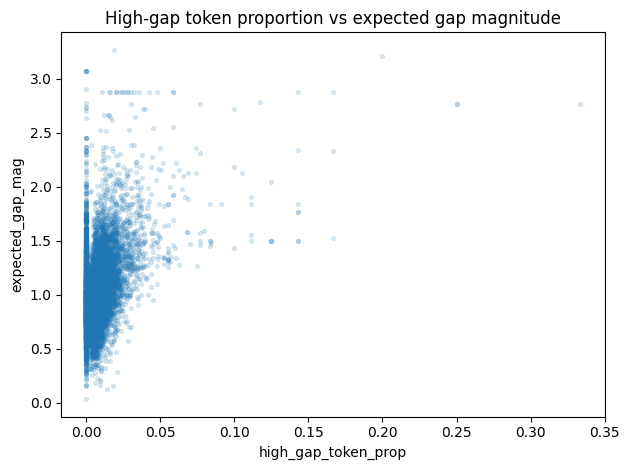

In [82]:
plt.figure()
plt.scatter(
    vad_posts["high_gap_token_prop"],
    vad_posts["expected_gap_mag"],
    alpha=0.15,
    s=8
)
plt.xlabel("high_gap_token_prop")
plt.ylabel("expected_gap_mag")
plt.title("High-gap token proportion vs expected gap magnitude")
plt.tight_layout()
plt.show()

### Regression with controls

These models test whether high-gap word usage predicts expected_gap_mag after controlling for:
- n_tokens
- shared lexicon coverage (matched_token_prop_used)
- clustering by user

In [83]:
reg_df = vad_posts.copy()
reg_df["log_n_tokens"] = np.log1p(reg_df["n_tokens"])
reg_df["user_id"] = reg_df["user_id"].astype(str)

if "mh_flag" in reg_df.columns:
    reg_df["mh_flag"] = reg_df["mh_flag"].astype(str)

formula_count = "expected_gap_mag ~ high_gap_token_count + log_n_tokens + matched_token_prop_used"
if "mh_flag" in reg_df.columns:
    formula_count += " + C(mh_flag)"

model_count = smf.ols(formula_count, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_count.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     222.1
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          3.70e-123
Time:                        02:48:41   Log-Likelihood:                -1692.3
No. Observations:                9168   AIC:                             3395.
Df Residuals:                    9163   BIC:                             3430.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [84]:
formula_prop = "expected_gap_mag ~ high_gap_token_prop + log_n_tokens + matched_token_prop_used"
if "mh_flag" in reg_df.columns:
    formula_prop += " + C(mh_flag)"

model_prop = smf.ols(formula_prop, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_prop.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                     326.2
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.48e-158
Time:                        02:48:46   Log-Likelihood:                -1675.0
No. Observations:                9168   AIC:                             3360.
Df Residuals:                    9163   BIC:                             3396.
Df Model:                           4                                         
Covariance Type:              cluster                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Controlling within-user

In [85]:
formula_count_fe = "expected_gap_mag ~ high_gap_token_count + log_n_tokens + matched_token_prop_used + C(user_id)"
if "mh_flag" in reg_df.columns:
    formula_count_fe += " + C(mh_flag)"

model_count_fe = smf.ols(formula_count_fe, data=reg_df).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df["user_id"]}
)

print(model_count_fe.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.391
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     51.50
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.73e-38
Time:                        02:48:54   Log-Likelihood:                -1189.0
No. Observations:                9168   AIC:                             3794.
Df Residuals:                    8460   BIC:                             8837.
Df Model:                         707                                         
Covariance Type:              cluster                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

c:\Users\hus44\AppData\Local\miniconda3\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 707, but rank is 4
  warnings.warn('covariance of constraints does not have full '


### MH-enriched low-gap control set

So the control set matches on affect and frequency and also MH-enriched on the same scale as the high-gap defined words

- matched on:
  - `valence_mean`
  - `arousal_mean`
  - `log_freq`
  - `mh_log_rr`

This creates a control group of **MH-enriched low-gap words**, which is a closer comparison for the selected treatment words.

In [86]:
# Build a shared lexicon feature table for treatment words and low-gap control candidates.

imb = pd.read_csv(imbault_path).copy()
imb["term"] = imb["word"].astype(str).str.strip().str.lower()

required_imb_cols = {
    "term", "valence_l1", "arousal_l1", "valence_l2", "arousal_l2"
}
missing_imb = required_imb_cols - set(imb.columns)
if missing_imb:
    raise ValueError(f"Imbault file missing required columns: {missing_imb}")

for col in ["valence_l1", "valence_l2", "arousal_l1", "arousal_l2"]:
    imb[col] = pd.to_numeric(imb[col], errors="coerce")

if "gap_mag" not in imb.columns:
    for col in ["gap_valence", "gap_arousal"]:
        imb[col] = pd.to_numeric(imb[col], errors="coerce")
    imb["gap_mag"] = np.sqrt(imb["gap_valence"]**2 + imb["gap_arousal"]**2)
else:
    imb["gap_mag"] = pd.to_numeric(imb["gap_mag"], errors="coerce")

imb = imb.dropna(subset=[
    "term", "valence_l1", "valence_l2", "arousal_l1", "arousal_l2", "gap_mag"
]).copy()

imb["valence_mean"] = imb[["valence_l1", "valence_l2"]].mean(axis=1)
imb["arousal_mean"] = imb[["arousal_l1", "arousal_l2"]].mean(axis=1)

lex = imb[["term", "gap_mag", "valence_mean", "arousal_mean"]].drop_duplicates("term").copy()

# Infer the same high-gap threshold mode used to create the treatment list file.
high_gap_name = high_gap_words_path.name.lower()
if "top10" in high_gap_name:
    THRESHOLD_MODE = "top10"
elif "abs15" in high_gap_name:
    THRESHOLD_MODE = "abs15"
else:
    THRESHOLD_MODE = "top5"

thr_top10 = float(lex["gap_mag"].quantile(0.90))
thr_top5 = float(lex["gap_mag"].quantile(0.95))
thr_abs15 = 1.5
thr_map = {"top10": thr_top10, "top5": thr_top5, "abs15": thr_abs15}
high_gap_threshold = thr_map[THRESHOLD_MODE]

full_high_gap_vocab = set(lex.loc[lex["gap_mag"] >= high_gap_threshold, "term"])

# Shared full-corpus token counts
token_counter = Counter()
mh_counter = Counter()
nonmh_counter = Counter()

for _, row in vad_posts.iterrows():
    toks = [str(t).lower() for t in row["tokens_list"]]
    token_counter.update(toks)

    mh_val = row["mh_flag"] if "mh_flag" in vad_posts.columns else 0
    is_mh = str(mh_val) in {"1", "1.0", "true", "True"}
    if is_mh:
        mh_counter.update(toks)
    else:
        nonmh_counter.update(toks)

lex["corpus_freq"] = lex["term"].map(lambda w: token_counter.get(w, 0)).astype(int)
lex["mh_token_count"] = lex["term"].map(lambda w: mh_counter.get(w, 0)).astype(int)
lex["nonmh_token_count"] = lex["term"].map(lambda w: nonmh_counter.get(w, 0)).astype(int)
lex["log_freq"] = np.log1p(lex["corpus_freq"])

# Shared MH enrichment score across the full token space.
alpha = 0.5
V = max(1, int(lex["term"].nunique()))
mh_total = sum(mh_counter.values())
nonmh_total = sum(nonmh_counter.values())

lex["mh_log_rr"] = (
    np.log((lex["mh_token_count"] + alpha) / (mh_total + alpha * V))
    - np.log((lex["nonmh_token_count"] + alpha) / (nonmh_total + alpha * V))
)

# Treatment words are the selected MH-enriched high-gap words from notebook 5.
treatment_words = set(high_gap_words)
treat_df = lex[lex["term"].isin(treatment_words)].copy()

# Build a stricter low-gap, MH-enriched control pool.
min_mh_tokens = 5
low_gap_cutoff = float(lex["gap_mag"].quantile(0.50))  # bottom 50% of gap_mag

control_pool_df = lex[
    (~lex["term"].isin(full_high_gap_vocab)) &
    (lex["gap_mag"] <= low_gap_cutoff) &
    (lex["mh_token_count"] >= min_mh_tokens) &
    (lex["corpus_freq"] > 0) &
    (lex["mh_log_rr"] > 0)
].copy()

print("Threshold mode inferred from filename:", THRESHOLD_MODE)
print("High-gap threshold:", high_gap_threshold)
print("Full high-gap vocab size:", len(full_high_gap_vocab))
print("Treatment words found in lexicon:", len(treat_df), "out of", len(treatment_words))
print("Control pool candidates:", len(control_pool_df))

treat_df[["term", "gap_mag", "valence_mean", "arousal_mean", "log_freq", "mh_log_rr"]].head()

Threshold mode inferred from filename: top5
High-gap threshold: 2.136969107761832
Full high-gap vocab size: 101
Treatment words found in lexicon: 30 out of 30
Control pool candidates: 151


,term,gap_mag,valence_mean,arousal_mean,log_freq,mh_log_rr
89,assessment,2.696145,4.400,3.820,2.772589,0.781180
91,assignment,2.635944,4.095,4.205,3.951244,0.379839
149,begin,2.386231,5.990,3.955,5.198497,0.017164
150,beginning,2.760652,6.360,4.380,6.300786,-0.083576
222,breathe,2.223083,6.740,3.625,3.988984,0.517989


In [87]:
def greedy_match_controls_mh(high_df, pool_df, feature_cols):
    """
    Greedy one-to-one matching of MH-enriched high-gap words to MH-enriched
    low-gap control words using standardized valence, arousal, frequency, and
    full-corpus MH enrichment.
    """
    required_cols = ["term", "gap_mag"] + feature_cols
    for name, df in [("high_df", high_df), ("pool_df", pool_df)]:
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{name} missing required columns: {missing}")

    high = high_df[required_cols].drop_duplicates("term").copy()
    pool = pool_df[required_cols].drop_duplicates("term").copy()

    combined = pd.concat([high[feature_cols], pool[feature_cols]], ignore_index=True)
    means = combined.mean()
    stds = combined.std(ddof=0).replace(0, 1)

    for col in feature_cols:
        high[f"z_{col}"] = (high[col] - means[col]) / stds[col]
        pool[f"z_{col}"] = (pool[col] - means[col]) / stds[col]

    pair_rows = []

    high = high.sort_values(["mh_log_rr", "valence_mean", "arousal_mean", "log_freq"]).reset_index(drop=True)

    for row in high.itertuples(index=False):
        if len(pool) == 0:
            break

        dist = np.sqrt(
            (pool["z_valence_mean"] - row.z_valence_mean) ** 2 +
            (pool["z_arousal_mean"] - row.z_arousal_mean) ** 2 +
            (pool["z_log_freq"] - row.z_log_freq) ** 2 +
            (pool["z_mh_log_rr"] - row.z_mh_log_rr) ** 2
        )

        best_idx = dist.idxmin()
        best = pool.loc[best_idx]

        pair_rows.append({
            "high_gap_word": row.term,
            "matched_control_word": best["term"],

            "high_gap_gap_mag": row.gap_mag,
            "control_gap_mag": best["gap_mag"],

            "high_gap_valence_mean": row.valence_mean,
            "control_valence_mean": best["valence_mean"],
            "abs_valence_diff": abs(best["valence_mean"] - row.valence_mean),

            "high_gap_arousal_mean": row.arousal_mean,
            "control_arousal_mean": best["arousal_mean"],
            "abs_arousal_diff": abs(best["arousal_mean"] - row.arousal_mean),

            "high_gap_log_freq": row.log_freq,
            "control_log_freq": best["log_freq"],
            "abs_log_freq_diff": abs(best["log_freq"] - row.log_freq),

            "high_gap_mh_log_rr": row.mh_log_rr,
            "control_mh_log_rr": best["mh_log_rr"],
            "abs_mh_log_rr_diff": abs(best["mh_log_rr"] - row.mh_log_rr),

            "match_distance_z": float(dist.loc[best_idx]),
        })

        pool = pool.drop(index=best_idx)

    return pd.DataFrame(pair_rows)

feature_cols = ["valence_mean", "arousal_mean", "log_freq", "mh_log_rr"]

matched_pairs_df = greedy_match_controls_mh(
    treat_df[["term", "gap_mag", "valence_mean", "arousal_mean", "log_freq", "mh_log_rr"]],
    control_pool_df[["term", "gap_mag", "valence_mean", "arousal_mean", "log_freq", "mh_log_rr"]],
    feature_cols=feature_cols
)

matched_control_words = set(matched_pairs_df["matched_control_word"])

matched_pairs_path = processed_dir / f"7_matched_mh_enriched_lowgap_controls_{THRESHOLD_MODE}.csv"
control_pool_path = processed_dir / f"7_mh_enriched_lowgap_control_pool_{THRESHOLD_MODE}.csv"

matched_pairs_df.to_csv(matched_pairs_path, index=False)
control_pool_df.to_csv(control_pool_path, index=False)

print("Saved:", matched_pairs_path)
print("Saved:", control_pool_path)
print("n matched control words:", len(matched_control_words))
matched_pairs_df.head(30)

Saved: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\7_matched_mh_enriched_lowgap_controls_top5.csv
Saved: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\7_mh_enriched_lowgap_control_pool_top5.csv
n matched control words: 30


,high_gap_word,matched_control_word,high_gap_gap_mag,control_gap_mag,high_gap_valence_mean,control_valence_mean,abs_valence_diff,high_gap_arousal_mean,control_arousal_mean,abs_arousal_diff,high_gap_log_freq,control_log_freq,abs_log_freq_diff,high_gap_mh_log_rr,control_mh_log_rr,abs_mh_log_rr_diff,match_distance_z
0,beginning,social,2.760652,0.572800,6.360,5.875,0.485,4.380,4.960,0.580,6.300786,6.723832,0.423047,-0.083576,0.064640,0.148215,0.907104
1,lucky,inspired,2.282389,0.554617,7.585,7.010,0.575,6.410,5.810,0.600,5.214936,4.465908,0.749028,-0.074610,0.048681,0.123292,1.052880
2,pet,existence,2.381953,0.698570,6.645,6.110,0.535,4.880,4.700,0.180,4.564348,4.442651,0.121697,-0.073090,0.077881,0.150971,0.532537
3,graduate,proud,2.339444,0.386394,7.075,7.190,0.115,5.675,5.515,0.160,4.127134,4.927254,0.800119,-0.051819,0.367477,0.419296,1.038439
4,great,important,2.721176,0.800062,7.460,6.440,1.020,5.500,4.835,0.665,7.382124,6.776507,0.605617,-0.041852,0.293915,0.335767,1.352419
5,thousand,degree,2.321314,0.973088,6.175,5.815,0.360,4.630,4.550,0.080,4.499810,4.682131,0.182322,0.006422,0.035716,0.029294,0.310484
6,begin,deep,2.386231,0.786448,5.990,5.360,0.630,3.955,4.285,0.330,5.198497,5.288267,0.089770,0.017164,0.069684,0.052520,0.614656
7,wonderful,ability,2.334202,0.550000,7.340,7.165,0.175,5.735,5.070,0.665,5.318120,4.955827,0.362293,0.032296,0.291276,0.258979,1.012215
8,special,run,3.209190,1.009604,7.250,5.925,1.325,5.065,5.380,0.315,6.011267,5.820083,0.191184,0.039980,0.024737,0.015243,1.018148
9,option,screen,2.328197,0.328024,5.900,5.650,0.250,4.255,4.220,0.035,5.323010,4.564348,0.758662,0.056688,0.124099,0.067412,0.626225


In [88]:
def token_count_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return sum(t in lex_set for t in toks)

def token_prop_in_set(tokens, lex_set):
    toks = [str(t).lower() for t in tokens]
    return sum(t in lex_set for t in toks) / max(1, len(toks))

vad_posts["control_affective_token_count"] = vad_posts["tokens_list"].map(
    lambda toks: token_count_in_set(toks, matched_control_words)
)

vad_posts["control_affective_token_prop"] = vad_posts["tokens_list"].map(
    lambda toks: token_prop_in_set(toks, matched_control_words)
)

vad_posts["has_control_affective_word"] = (
    vad_posts["control_affective_token_count"] > 0
).astype(int)

print("Treatment/control pair preview:")
display_cols = [
    "high_gap_word",
    "matched_control_word",
    "abs_valence_diff",
    "abs_arousal_diff",
    "abs_log_freq_diff",
    "abs_mh_log_rr_diff",
    "match_distance_z",
]
matched_pairs_df[display_cols]

Treatment/control pair preview:


,high_gap_word,matched_control_word,abs_valence_diff,abs_arousal_diff,abs_log_freq_diff,abs_mh_log_rr_diff,match_distance_z
0,beginning,social,0.485,0.580,0.423047,0.148215,0.907104
1,lucky,inspired,0.575,0.600,0.749028,0.123292,1.052880
2,pet,existence,0.535,0.180,0.121697,0.150971,0.532537
3,graduate,proud,0.115,0.160,0.800119,0.419296,1.038439
4,great,important,1.020,0.665,0.605617,0.335767,1.352419
5,thousand,degree,0.360,0.080,0.182322,0.029294,0.310484
6,begin,deep,0.630,0.330,0.089770,0.052520,0.614656
7,wonderful,ability,0.175,0.665,0.362293,0.258979,1.012215
8,special,run,1.325,0.315,0.191184,0.015243,1.018148
9,option,screen,0.250,0.035,0.758662,0.067412,0.626225


Compare high-gap words to matched non-high-gap affective words

In [89]:
comparison_groups = pd.DataFrame({
    "group": [
        "contains_high_gap_word",
        "does_not_contain_high_gap_word",
        "contains_matched_control_affective_word",
        "does_not_contain_matched_control_affective_word",
    ],
    "n_posts": [
        int((vad_posts["has_high_gap_word"] == 1).sum()),
        int((vad_posts["has_high_gap_word"] == 0).sum()),
        int((vad_posts["has_control_affective_word"] == 1).sum()),
        int((vad_posts["has_control_affective_word"] == 0).sum()),
    ],
    "mean_expected_gap_mag": [
        vad_posts.loc[vad_posts["has_high_gap_word"] == 1, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["has_high_gap_word"] == 0, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["has_control_affective_word"] == 1, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["has_control_affective_word"] == 0, "expected_gap_mag"].mean(),
    ],
    "median_expected_gap_mag": [
        vad_posts.loc[vad_posts["has_high_gap_word"] == 1, "expected_gap_mag"].median(),
        vad_posts.loc[vad_posts["has_high_gap_word"] == 0, "expected_gap_mag"].median(),
        vad_posts.loc[vad_posts["has_control_affective_word"] == 1, "expected_gap_mag"].median(),
        vad_posts.loc[vad_posts["has_control_affective_word"] == 0, "expected_gap_mag"].median(),
    ]
})

comparison_groups

,group,n_posts,mean_expected_gap_mag,median_expected_gap_mag
0,contains_high_gap_word,6482,1.076600,1.030333
1,does_not_contain_high_gap_word,2686,1.003470,0.956471
2,contains_matched_control_affective_word,4041,0.946611,0.930602
3,does_not_contain_matched_control_affective_word,5127,1.140743,1.089155


In [90]:
with_high_gap = vad_posts.loc[
    vad_posts["has_high_gap_word"] == 1, "expected_gap_mag"
].dropna()

without_high_gap = vad_posts.loc[
    vad_posts["has_high_gap_word"] == 0, "expected_gap_mag"
].dropna()

with_control = vad_posts.loc[
    vad_posts["has_control_affective_word"] == 1, "expected_gap_mag"
].dropna()

without_control = vad_posts.loc[
    vad_posts["has_control_affective_word"] == 0, "expected_gap_mag"
].dropna()

if len(with_high_gap) > 0 and len(without_high_gap) > 0:
    mw_high_vs_none = mannwhitneyu(
        with_high_gap,
        without_high_gap,
        alternative="two-sided"
    )
else:
    mw_high_vs_none = None

if len(with_control) > 0 and len(without_control) > 0:
    mw_control_vs_none = mannwhitneyu(
        with_control,
        without_control,
        alternative="two-sided"
    )
else:
    mw_control_vs_none = None

print("Mann-Whitney: selected high-gap word present vs absent")
print(mw_high_vs_none)
print()
print("Mann-Whitney: matched control affective word present vs absent")
print(mw_control_vs_none)

Mann-Whitney: selected high-gap word present vs absent
MannwhitneyuResult(statistic=np.float64(9867227.5), pvalue=np.float64(7.217130615954745e-24))

Mann-Whitney: matched control affective word present vs absent
MannwhitneyuResult(statistic=np.float64(7148406.5), pvalue=np.float64(1.2330929124318792e-143))


In [91]:
reg_df2 = vad_posts.copy()
reg_df2["log_n_tokens"] = np.log1p(reg_df2["n_tokens"])

formula_compare = (
    "expected_gap_mag ~ high_gap_token_count + control_affective_token_count "
    "+ log_n_tokens + matched_token_prop_used"
)
if "mh_flag" in reg_df2.columns:
    formula_compare += " + C(mh_flag)"

model_compare = smf.ols(formula_compare, data=reg_df2).fit(
    cov_type="cluster",
    cov_kwds={"groups": reg_df2["user_id"]}
)

print(model_compare.summary())

                            OLS Regression Results                            
Dep. Variable:       expected_gap_mag   R-squared:                       0.327
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     185.0
Date:                Fri, 27 Mar 2026   Prob (F-statistic):          1.38e-125
Time:                        02:49:40   Log-Likelihood:                -1653.3
No. Observations:                9168   AIC:                             3319.
Df Residuals:                    9162   BIC:                             3361.
Df Model:                           5                                         
Covariance Type:              cluster                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

### Ablation test

- Loads only Imbault
- Re-scores only the posts that contain at least one high-gap word or matched-control word

In [92]:
imb_l1 = (
    imb[["term", "valence_l1", "arousal_l1"]]
    .rename(columns={"valence_l1": "valence", "arousal_l1": "arousal"})
    .dropna(subset=["term", "valence", "arousal"])
    .drop_duplicates("term")
    .copy()
)

imb_l2 = (
    imb[["term", "valence_l2", "arousal_l2"]]
    .rename(columns={"valence_l2": "valence", "arousal_l2": "arousal"})
    .dropna(subset=["term", "valence", "arousal"])
    .drop_duplicates("term")
    .copy()
)

def build_lexicon_maps(lex_df: pd.DataFrame):
    lex_df = lex_df.copy()
    lex_df["term"] = lex_df["term"].astype(str).str.strip().str.lower()

    uni = lex_df[~lex_df["term"].str.contains(r"\s+", regex=True)].copy()
    mwe = lex_df[lex_df["term"].str.contains(r"\s+", regex=True)].copy()

    unigram_map = {
        row.term: (float(row.valence), float(row.arousal))
        for row in uni.itertuples(index=False)
    }

    mwe_by_len = defaultdict(dict)
    for row in mwe.itertuples(index=False):
        toks = tuple(row.term.split())
        mwe_by_len[len(toks)][toks] = (float(row.valence), float(row.arousal))

    mwe_lengths = sorted(mwe_by_len.keys(), reverse=True)
    return unigram_map, mwe_by_len, mwe_lengths

imb_l1_uni, imb_l1_mwe, imb_l1_mwe_lens = build_lexicon_maps(imb_l1)
imb_l2_uni, imb_l2_mwe, imb_l2_mwe_lens = build_lexicon_maps(imb_l2)

print("Imbault L1 unigrams:", len(imb_l1_uni))
print("Imbault L2 unigrams:", len(imb_l2_uni))

Imbault L1 unigrams: 2008
Imbault L2 unigrams: 2008


In [93]:
def score_tokens_with_lexicon(tokens, unigram_map, mwe_by_len, mwe_lengths):
    toks = [str(t).lower() for t in tokens]
    n_tokens = len(toks)

    hits = []
    i = 0
    while i < n_tokens:
        matched = False

        for L in mwe_lengths:
            if i + L <= n_tokens:
                phrase = tuple(toks[i:i+L])
                if phrase in mwe_by_len[L]:
                    val, aro = mwe_by_len[L][phrase]
                    hits.append({
                        "term": " ".join(phrase),
                        "valence": val,
                        "arousal": aro,
                        "span_len": L,
                        "match_type": "mwe",
                    })
                    i += L
                    matched = True
                    break

        if matched:
            continue

        tok = toks[i]
        if tok in unigram_map:
            val, aro = unigram_map[tok]
            hits.append({
                "term": tok,
                "valence": val,
                "arousal": aro,
                "span_len": 1,
                "match_type": "unigram",
            })

        i += 1

    if not hits:
        return {
            "expected_valence": np.nan,
            "expected_arousal": np.nan,
            "matched_items": 0,
            "matched_token_count": 0,
            "matched_token_prop": 0.0,
            "matched_terms": json.dumps([]),
        }

    vals = [h["valence"] for h in hits]
    aros = [h["arousal"] for h in hits]
    matched_token_count = int(sum(h["span_len"] for h in hits))

    return {
        "expected_valence": float(np.mean(vals)),
        "expected_arousal": float(np.mean(aros)),
        "matched_items": int(len(hits)),
        "matched_token_count": matched_token_count,
        "matched_token_prop": float(matched_token_count / max(1, n_tokens)),
        "matched_terms": json.dumps([h["term"] for h in hits[:100]]),
    }

def compute_gap_mag_from_tokens(tokens):
    l1 = score_tokens_with_lexicon(tokens, imb_l1_uni, imb_l1_mwe, imb_l1_mwe_lens)
    l2 = score_tokens_with_lexicon(tokens, imb_l2_uni, imb_l2_mwe, imb_l2_mwe_lens)

    if pd.isna(l1["expected_valence"]) or pd.isna(l2["expected_valence"]):
        return np.nan

    gap_val = l2["expected_valence"] - l1["expected_valence"]
    gap_aro = l2["expected_arousal"] - l1["expected_arousal"]
    return float(np.sqrt(gap_val**2 + gap_aro**2))

def remove_words(tokens, word_set):
    return [t for t in tokens if str(t).lower() not in word_set]

In [94]:
# Only rescore posts where removing something could matter.
ablation_df = vad_posts[
    (vad_posts["high_gap_token_count"] > 0) |
    (vad_posts["control_affective_token_count"] > 0)
].copy()

print("Posts entering ablation:", len(ablation_df))

Posts entering ablation: 7581


In [95]:
ablation_df["gap_mag_after_high_gap_removal"] = ablation_df["tokens_list"].progress_map(
    lambda toks: compute_gap_mag_from_tokens(remove_words(toks, high_gap_words))
)

ablation_df["gap_mag_after_control_removal"] = ablation_df["tokens_list"].progress_map(
    lambda toks: compute_gap_mag_from_tokens(remove_words(toks, matched_control_words))
)

ablation_df["delta_gap_mag_high_removed"] = (
    ablation_df["expected_gap_mag"] - ablation_df["gap_mag_after_high_gap_removal"]
)

ablation_df["delta_gap_mag_control_removed"] = (
    ablation_df["expected_gap_mag"] - ablation_df["gap_mag_after_control_removal"]
)

ablation_df["delta_per_high_gap_token"] = (
    ablation_df["delta_gap_mag_high_removed"] /
    ablation_df["high_gap_token_count"].replace(0, np.nan)
)

ablation_df["delta_per_control_token"] = (
    ablation_df["delta_gap_mag_control_removed"] /
    ablation_df["control_affective_token_count"].replace(0, np.nan)
)

ablation_df[[
    "expected_gap_mag",
    "gap_mag_after_high_gap_removal",
    "gap_mag_after_control_removal",
    "delta_gap_mag_high_removed",
    "delta_gap_mag_control_removed"
]].head()

100%|██████████| 7581/7581 [00:01<00:00, 6817.74it/s]


,expected_gap_mag,gap_mag_after_high_gap_removal,gap_mag_after_control_removal,delta_gap_mag_high_removed,delta_gap_mag_control_removed
0,1.070193,1.070193,1.239252,-2.220446e-16,-1.690588e-01
1,1.164314,0.909812,1.164314,2.545021e-01,0.000000e+00
3,1.013025,0.943713,1.034324,6.931168e-02,-2.129933e-02
4,2.044771,1.722157,2.044771,3.226140e-01,-4.440892e-16
5,0.904562,0.797679,0.904562,1.068828e-01,0.000000e+00


In [96]:
ablation_summary = pd.DataFrame({
    "metric": [
        "n_ablation_posts",
        "mean_delta_gap_mag_high_removed",
        "mean_delta_gap_mag_control_removed",
        "median_delta_gap_mag_high_removed",
        "median_delta_gap_mag_control_removed",
        "mean_delta_per_high_gap_token",
        "mean_delta_per_control_token",
    ],
    "value": [
        len(ablation_df),
        ablation_df["delta_gap_mag_high_removed"].mean(),
        ablation_df["delta_gap_mag_control_removed"].mean(),
        ablation_df["delta_gap_mag_high_removed"].median(),
        ablation_df["delta_gap_mag_control_removed"].median(),
        ablation_df["delta_per_high_gap_token"].mean(),
        ablation_df["delta_per_control_token"].mean(),
    ]
})

ablation_summary

,metric,value
0,n_ablation_posts,7581.000000
1,mean_delta_gap_mag_high_removed,0.208161
2,mean_delta_gap_mag_control_removed,-0.042738
3,median_delta_gap_mag_high_removed,0.161114
4,median_delta_gap_mag_control_removed,-0.003124
5,mean_delta_per_high_gap_token,0.169615
6,mean_delta_per_control_token,-0.051485


In [97]:
paired_ablation = ablation_df[
    (ablation_df["high_gap_token_count"] > 0) &
    (ablation_df["control_affective_token_count"] > 0) &
    ablation_df["delta_per_high_gap_token"].notna() &
    ablation_df["delta_per_control_token"].notna()
].copy()

print("n paired posts:", len(paired_ablation))

if len(paired_ablation) > 0:
    wilcox_raw = wilcoxon(
        paired_ablation["delta_gap_mag_high_removed"],
        paired_ablation["delta_gap_mag_control_removed"],
        zero_method="wilcox",
        alternative="greater"
    )

    wilcox_norm = wilcoxon(
        paired_ablation["delta_per_high_gap_token"],
        paired_ablation["delta_per_control_token"],
        zero_method="wilcox",
        alternative="greater"
    )

    print("Wilcoxon on raw delta:")
    print(wilcox_raw)
    print()
    print("Wilcoxon on per-token delta:")
    print(wilcox_norm)
else:
    print("No paired posts available for Wilcoxon comparison.")

n paired posts: 2942
Wilcoxon on raw delta:
WilcoxonResult(statistic=np.float64(4327814.0), pvalue=np.float64(0.0))

Wilcoxon on per-token delta:
WilcoxonResult(statistic=np.float64(4327095.0), pvalue=np.float64(0.0))


### Saving results tables

In [98]:
main_results = pd.DataFrame({
    "analysis": [
        "spearman_count_statistic",
        "spearman_count_pvalue",
        "spearman_prop_statistic",
        "spearman_prop_pvalue",
        "spearman_type_statistic",
        "spearman_type_pvalue",
        "mean_gap_if_has_high_gap",
        "mean_gap_if_no_high_gap",
        "mean_gap_if_has_control_affective",
        "mean_gap_if_no_control_affective",
        "mean_delta_high_removed",
        "mean_delta_control_removed",
        "mean_delta_per_high_gap_token",
        "mean_delta_per_control_token",
    ],
    "value": [
        corr_count.statistic,
        corr_count.pvalue,
        corr_prop.statistic,
        corr_prop.pvalue,
        corr_type.statistic,
        corr_type.pvalue,
        vad_posts.loc[vad_posts["high_gap_token_count"] > 0, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["high_gap_token_count"] == 0, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["control_affective_token_count"] > 0, "expected_gap_mag"].mean(),
        vad_posts.loc[vad_posts["control_affective_token_count"] == 0, "expected_gap_mag"].mean(),
        ablation_df["delta_gap_mag_high_removed"].mean(),
        ablation_df["delta_gap_mag_control_removed"].mean(),
        ablation_df["delta_per_high_gap_token"].mean(),
        ablation_df["delta_per_control_token"].mean(),
    ]
})

main_results.to_csv(analysis_summary_path, index=False)
ablation_summary.to_csv(ablation_summary_path, index=False)
ablation_df.to_csv(post_level_ablation_path, index=False)

print("Wrote:", analysis_summary_path)
print("Wrote:", ablation_summary_path)
print("Wrote:", post_level_ablation_path)

main_results

Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\7_high_gap_influence_summary.csv
Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\7_high_gap_ablation_summary.csv
Wrote: C:\Users\hus44\Code\Directed-Reading-Project\data\processed\7_high_gap_ablation_postlevel.csv


,analysis,value
0,spearman_count_statistic,1.836188e-01
1,spearman_count_pvalue,2.460763e-70
2,spearman_prop_statistic,3.358446e-01
3,spearman_prop_pvalue,1.570013e-240
4,spearman_type_statistic,1.442212e-01
5,spearman_type_pvalue,8.389919e-44
6,mean_gap_if_has_high_gap,1.076600e+00
7,mean_gap_if_no_high_gap,1.003470e+00
8,mean_gap_if_has_control_affective,9.466105e-01
9,mean_gap_if_no_control_affective,1.140743e+00
